In [246]:
import os
import json
import glob
import matplotlib.pyplot as plt

import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator
from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost
from qaoa_parameter_setting.utils.analysis import quantile, mean_obj, standard_error_mean

In [247]:
def load_json(partial_name, directory="."):

    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)

    if not matches:
        raise FileNotFoundError(f"No JSON files found matching: {partial_name}")

    with open(matches[0], "r") as f:
        data = json.load(f)
    return data

In [248]:
def energy_data(folder, short_name, depth, max_cuts, min_cuts, top_pc):
    
    all_summaries = []
    matches = []
    all_methods = []
    file_data   = []
    
    for n in range(num_files):
        prefix = f"data/hardware/{folder}/00{n}{short_name}_{depth}"
        found = glob.glob(prefix + "*.json")
        matches.extend(found)
    
    for fname in matches:
        try:
            with open(fname, "r") as fin:
                res_summary = json.load(fin)
    
            basename = os.path.basename(fname)
            prefix_digits = ''.join([c for c in basename if c.isdigit()][:3])
            n = int(prefix_digits)
    
            graph = load_graph(f"instances/{folder}/00{n}{instance}")
            denom = max_cuts[n] - min_cuts[n]
            denom = denom if denom != 0 else np.nan
    
            methods = set()
            energies = {}
    
            means     = []
            sems      = []
    
            for res in res_summary:
                meta = res.get("metadata")
                if not meta:
                    continue
    
                counts = res.get("counts")
                if counts is None:
                    continue
    
                # Compute cost + shots
                mc_cost = counts_to_maxcut_cost(graph, counts)
                shots   = sum(counts.values())
                mc_cost_2= {k: int(v * shots) for k, v in  mc_cost.items()}
                sk=sorted(mc_cost_2.keys(), reverse=True)
                y_vals = np.cumsum([mc_cost_2[x] for x in sk])
                threshold=int(4096*top_pc/100)
                idx = np.searchsorted(y_vals, threshold)
                top_mc_cost = {k: mc_cost_2[k] for k in sk[:idx+1]}
                top_mc_cost[sk[idx]]-= y_vals[idx]-threshold
                top_mc_cost= {k: top_mc_cost[k]/threshold for k in sk[:idx+1]}

                # Normalized mean + sem
                mean_norm = 100 * (mean_obj(top_mc_cost) - min_cuts[n]) / denom
                sem_norm  = 100 * standard_error_mean(top_mc_cost, threshold) / denom
    
                means.append(mean_norm)
                sems.append(sem_norm)
    
                # Metadata extraction
                circ_meta = meta.get("circuit_metadata", {})
                label = circ_meta.get("method")
                val   = circ_meta.get("eval_energy")
    
                methods.add(label)
                energies.setdefault(label, []).append([val, mean_norm, sem_norm])
    
            all_methods.append(methods)
            file_data.append(energies)
    
        except FileNotFoundError:
            print(f"Missing file: {fname}")
    
        print(n)

    
    # Find shared labels
    shared_labels = set.intersection(*all_methods)
    # print("Shared labels:", shared_labels)
    
    # Collect energies per label 
    energy_dict = {label: [] for label in shared_labels}
    for energies in file_data:
        for label in shared_labels:
            if label in energies:
                energy_dict[label].append(energies[label])
                
    return shared_labels, energy_dict

In [249]:
prefix_map = {
    "F": ["Fourier", 0],
    "FA": ["fixed angles", 1],
    "I": ["INTERP", 2],
    "TQA": ["TQA", 3],
    "PT": ["parameter transfer", 4],
    "LR": ["linear ramp", 5]
}

evaluator_map = {
    "MPS": 0,
    "MPSAer": 0,
    "PP": 1,
   
}
def expand_abbreviation(abbr, prefix_map, depth):
    parts = abbr.split('_')
    if parts[2]=="opt" and parts[0]!="LR":
        expanded= f"reoptimized {prefix_map[parts[0]][0]} with {parts[1]}"
    else:
        expanded= f"{prefix_map[parts[0]][0]} with {parts[1]}"
    return expanded



In [250]:
depths   = [2,6]        # depth value
num_files   = 10   # number of files 


# instance = "_30nodes_random3regular.json"
# short_name = "N30R3R"
# folder = "random_regular"
# instance = "_7_3_heavyhex_144nodes_weighted.json"
# short_name = "N144HH73"
# folder = "heavy_hex"
# instance = "_40nodes_erdosrenyi20percent.json"
# short_name = "N40ER20"
# folder = "erdos_renyi"
instance = "_100nodes_2swap_layers.json"
short_name = "N100L2S2"
folder = "line_to_full"


In [251]:
result_repo=f"../QAOA-Parameter-Setting/data/training/{folder}"
max_cuts=[]
min_cuts=[]
ar_diffs=[]
for n in range(num_files):
    data = load_json(f"00{n}{short_name}_MC", directory=result_repo)
    cost_op = SparsePauliOp.from_list(data["cost_operator"])
    max_cut, min_cut, ar = solve_max_cut(cost_op,  data["1"]["energy"])
    ar_diff= ar*(max_cut-min_cut)- data["1"]["energy"]
    max_cuts.append(max_cut)
    min_cuts.append(min_cut)
    ar_diffs.append(ar_diff)
    print(n)

0
1
2
3
4
5
6
7
8
9


In [269]:
shared_labels={}
energy_dict={}
pc=100         # The top percent of shots to be averaged
for depth in depths:
    labels, energies=energy_data(folder, short_name, depth, max_cuts, min_cuts, pc)
    shared_labels[depth]=labels
    energy_dict[depth]=energies

0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9


In [270]:
colors = [
    "#e41a1c",  
    "#377eb8",  
    "#4daf4a",  
    "#984ea3",  
    "#ff7f00",  
    "#ffff33",  
    "#a65628",  
    "#f781bf",  
    "#999999",  
    "#00c0ff",  
    "#ff00aa",  
    "#00ff80",  
]

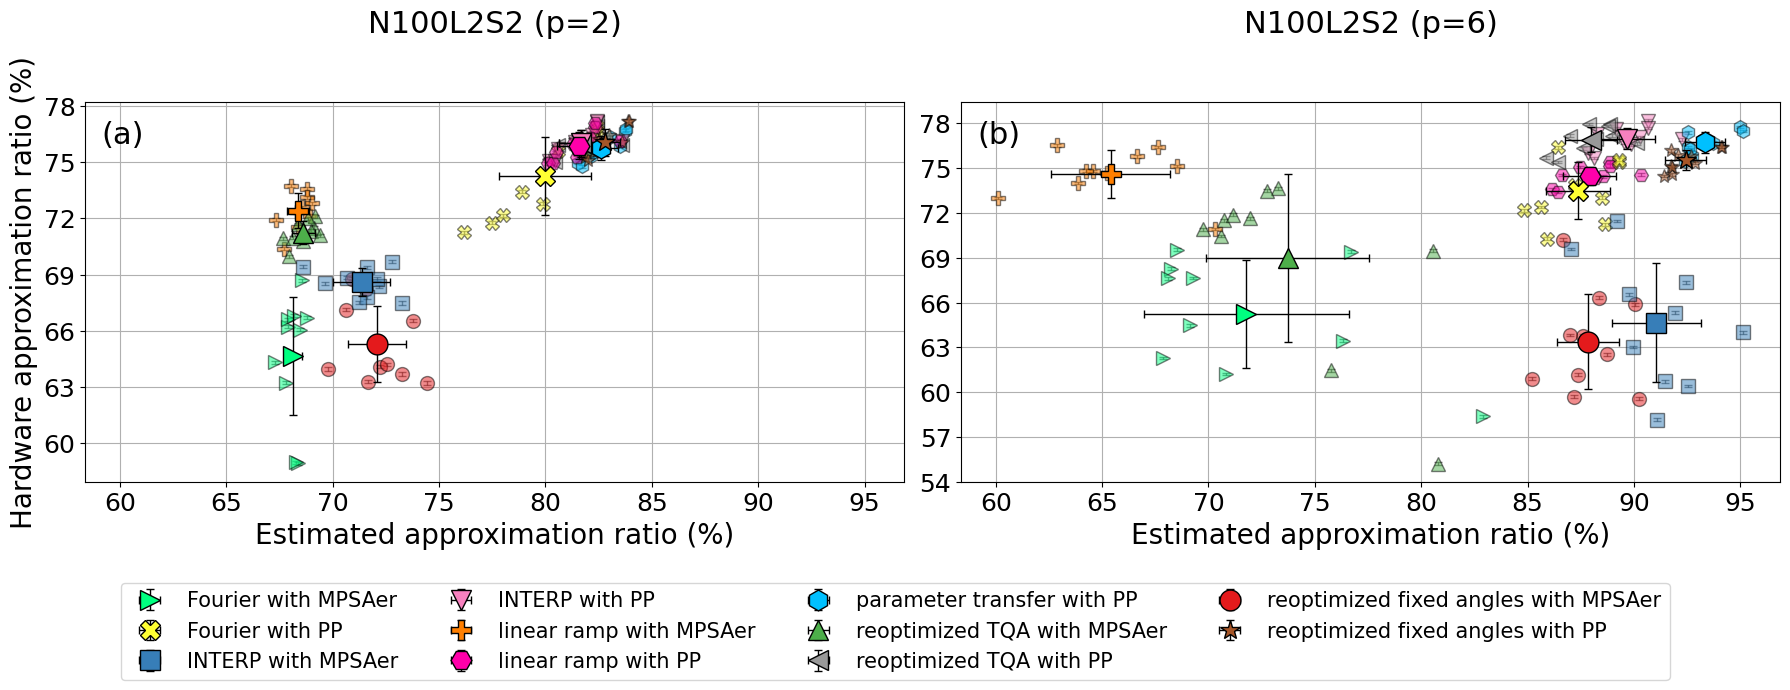

In [272]:
from matplotlib.ticker import MaxNLocator

eval_list=["MPSAer", "PP"]

opts = {"mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1}
marker_styles = [
    "o", "s", "^", "D", "P", "X", "*", "v",
    "<", "h", "H", "d", "+", "x", "|", "_", ">"
]

fig, axs = plt.subplots(1, len(depths), figsize=(9* len(depths), 6), sharex=True)

if len(depths) == 1:
    axs = [axs]

all_handles = []
all_labels  = []
shared_labels_d = {}

for ax, depth in zip(axs, depths):

    shared_labels_d[depth] = {
        x for x in shared_labels[depth]
        if any(part == k for part in x.split('_') for k in eval_list)
    }

    for label in shared_labels_d[depth]:
        parts = label.split('_')
        ind = evaluator_map[parts[1]] * len(prefix_map) + prefix_map[parts[0]][1] - 1

        arr = np.array(energy_dict[depth][label])
        arr0 = (arr[:, 0, 0] + np.array(ar_diffs).T) / (np.array(max_cuts).T - np.array(min_cuts).T)

        ax.errorbar(
            100 * arr0.flatten(), arr[:, 0, 1], yerr=arr[:, 0, 2],
            fmt=marker_styles[ind], linestyle="none",
            color=colors[ind % len(colors)], alpha=0.5, ms=10,
            **opts
        )

        h = ax.errorbar(
            np.average(100 * arr0.flatten()), np.average(arr[:, 0, 1]),
            xerr=np.std(100 * arr0.flatten()), yerr=np.std(arr[:, 0, 1]),
            fmt=marker_styles[ind],
            label=expand_abbreviation(label, prefix_map, depth),
            linestyle="none",
            color=colors[ind % len(colors)], zorder=10, ms=15,
            **opts
        )

        all_handles.append(h)
        all_labels.append(expand_abbreviation(label, prefix_map, depth))

    ax.grid(True)
    ax.set_xlabel("Estimated approximation ratio (%)", fontsize=20)
    ax.set_title(f"{short_name} (p={depth})", fontsize=22, pad=50)
    ax.tick_params(axis="both", labelsize=18)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

axs[0].set_ylabel("Hardware approximation ratio (%)", fontsize=20)

# Sorting legends
labels_handles_sorted = sorted(zip(all_labels, all_handles), key=lambda x: x[0])
unique_labels_handles = dict(labels_handles_sorted)   # <-- correct
labels_unique  = list(unique_labels_handles.keys())
handles_unique = list(unique_labels_handles.values())

fig.legend(
    handles_unique,
    labels_unique,
    fontsize=15,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    borderaxespad=0
)

subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

for ax, label in zip(axs, subplot_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,
        fontsize=22,
        va="top",
        ha="left"
    )



fig.tight_layout(rect=[0, 0.05, 1, 1])
depth_str = "_".join(str(d) for d in depths)
fig.savefig(f"{short_name}_{depth_str}_HW_r_{pc}pc.pdf", bbox_inches="tight")

In [263]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
    
def compact_method_label(label, index=None):
    parts = label.split('_')
    if len(parts) < 2:
        return label
    method, evaluator = parts[0], parts[1]
    star = '$^\star$' if "opt" in parts and parts[0]!= "LR"  else ""
    prefix = f"{index}. " if index is not None else ''
    return f"{prefix}({method}, {evaluator}){star}"


def dataset_test(data, depth, label="Dataset"):

    method_name=f"Methods(p={depth})"
    # Build DataFrame
    df = pd.DataFrame({
        'score': np.concatenate(list(data.values())),
        method_name: sum([[m]*len(v) for m,v in data.items()], [])
    })

    # Kruskal–Wallis test
    groups = [df.loc[df[method_name]==m, 'score'] for m in data.keys()]
    H, p = stats.kruskal(*groups)

    df[method_name] = df[method_name].str.rsplit("_", n=1).str[0]

    # Medians for ordering
    group_medians = df.groupby(method_name)['score'].median()

    # Conover–Iman posthoc with Holm correction
    conover_results = sp.posthoc_conover(
        df, val_col='score', group_col=method_name, p_adjust='holm'
    )

    # Order rows/cols by descending median
    order = group_medians.sort_values(ascending=False).index
    results = conover_results.loc[order, order]
    
    # Apply upper-triangular mask (remove symmetric duplicates)
    results_ut = results.copy().astype("object")
    n = results_ut.shape[0]
    for i in range(n):
        for j in range(n):
            if i >= j:
                results_ut.iat[i, j] = ""   

    # Add median column (preserving order)
    results_ut["Median"] = group_medians[order]
    results_ut.index.name = None
    
    renamed = {
        name: compact_method_label(name, index=i+1)
        for i, name in enumerate(order)
    }
    results_ut.rename(index=renamed, inplace=True)
    results_ut.columns = [f"{i}." for i in range(1, len(results_ut.columns))] + ["Median"]
    results_ut.columns.name = method_name

    # Print summary
    print(f"\nKruskal–Wallis omnibus test on {label}: H={H:.3f}, p={p:.3e}")
    print(f"\nConover–Iman test (Holm correction) on {label}:\n", results_ut)

    return H, p, results_ut


est_results={}
hw_results={}
for depth in depths:
    data_est={}
    data_hw={}
    for i, label in enumerate(shared_labels_d[depth]):
        arr = np.array(energy_dict[depth][label])
        arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
        data_est[label]= 100*arr0.flatten()
        data_hw[label]= arr[:, 0, 1]
    # Run for both datasets
    _, _, est_results[depth] = dataset_test(data_est,depth, label="estimated ratios")
    _, _, hw_results[depth]  = dataset_test(data_hw,depth, label="hardware ratios")






Kruskal–Wallis omnibus test on estimated ratios: H=93.374, p=1.145e-15

Conover–Iman test (Holm correction) on estimated ratios:
 Methods(p=2)             1.   2.        3.        4.        5.        6.  \
1. (FA, PP)$^\star$          1.0  0.039654  0.046116  0.009002  0.000175   
2. (PT, PP)                       0.354501  0.388526  0.103524  0.003929   
3. (I, PP)                                       1.0       1.0       1.0   
4. (TQA, PP)$^\star$                                       1.0  0.991276   
5. (LR, PP)                                                          1.0   
6. (F, PP)                                                                 
7. (FA, MPSAer)$^\star$                                                    
8. (I, MPSAer)                                                             
9. (TQA, MPSAer)$^\star$                                                   
10. (LR, MPSAer)                                                           
11. (F, MPSAer)                  

In [264]:
import pandas as pd
import re

def p_to_colored_cell(p):
    """Return a LaTeX \\cellcolor based on p-value (no stars)."""
    if p == "" or pd.isna(p):
        return "--"

    p = float(p)

    if p < 0.001:
        return f"{{\\cellcolor[HTML]{{00441B}}}} \\color[HTML]{{F1F1F1}} {p:.1e}"
    elif p < 0.01:
        return f"{{\\cellcolor[HTML]{{309950}}}} \\color[HTML]{{F1F1F1}} {p:.1e}"
    elif p < 0.05:
        return f"{{\\cellcolor[HTML]{{B5E1AE}}}} \\color[HTML]{{000000}} {p:.1e}"
    elif p==1:
        return p
    else:
        return f"{p:.1e}"


def colorize_df(df):
    df_colored = df.copy().astype("object")
    for col in df.columns[:-1]:
        df_colored[col] = df[col].apply(p_to_colored_cell)
    return df_colored

def df_to_latex_with_hlines(df):
    latex = df.to_latex(
        escape=False,
        float_format="%.3g",
        index=True,
        index_names=True,
        na_rep="--",
        column_format="l" + "c"*(df.shape[1]),
 
    )
    latex = (latex
             .replace("\\toprule","\\hline\n")
             .replace("\\midrule","\\hline\n")
             .replace("\\bottomrule","\\hline\n")
             .replace("_","\\_"))
    return latex

graph_patterns = [
    (r"N(\d+)HH(\d+)", lambda n, x: f"{n}-node heavy-hex graphs"),
    (r"N(\d+)R(\d+)R", lambda n, k: f"{n}-node random {k}-regular graphs"),
    (r"N(\d+)L2S(\d+)", lambda n, s: f"{n}-node line-to-full graphs with {s} swap layers"),
    (r"N(\d+)ER(\d+)", lambda n, p: f"{n}-node Erdos-Renyi graphs with {p}\% edge probability"),
]

def graph_description(short_name):
    for pattern, fmt in graph_patterns:
        m = re.fullmatch(pattern, short_name)
        if m:
            return fmt(*map(int, m.groups()))
    raise ValueError(f"Unrecognized graph topology: {short_name}")



In [265]:
# Export tables
latex_code= {}
for depth in depths:
    est_colored = colorize_df(est_results[depth])
    hw_colored = colorize_df(hw_results[depth])
    
    est_latex = df_to_latex_with_hlines(est_colored)
    hw_latex = df_to_latex_with_hlines(hw_colored)
    
    latex_code[depth] = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\resizebox{\\columnwidth}{!}{%\n" +
        est_latex +
        "}\n"
        "\\vspace{0.5em}\n\n"
        "\\resizebox{\\columnwidth}{!}{%\n" +
        hw_latex +
        "}\n"+
        "\\caption{Conover–Iman post-hoc test with Holm correction on estimated(top) and hardware(bottom) ratios generated from "+
        f"{num_files} {graph_description(short_name)} at $p={depth}$. "+
        "\\raisebox{0.7ex}{\\colorbox[HTML]{B5E1AE}{\\hspace{1em}}} indicates p-values less than 0.05, " + 
        "\\raisebox{0.7ex}{\\colorbox[HTML]{309950}{\\hspace{1em}}} indicates p-values less than 0.01, "+
        "and \\raisebox{0.7ex}{\\colorbox[HTML]{00441B}{\\hspace{1em}}} indicates p-values less than 0.001.}\n" 
        "\\end{table}"
    )

In [268]:
print(latex_code[depths[1]])

\begin{table}[ht]
\centering
\resizebox{\columnwidth}{!}{%
\begin{tabular}{lcccccccccccc}
\hline

Methods(p=6) & 1. & 2. & 3. & 4. & 5. & 6. & 7. & 8. & 9. & 10. & 11. & Median \\
\hline

1. (PT, PP) & -- & 1 & {\cellcolor[HTML]{B5E1AE}} \color[HTML]{000000} 1.1e-02 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.1e-06 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 4.5e-12 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.8e-12 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 5.3e-14 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.0e-12 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 8.3e-25 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.2e-26 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.6e-30 & 93 \\
2. (FA, PP)$^\star$ & -- & -- & 3.3e-01 & {\cellcolor[HTML]{309950}} \color[HTML]{F1F1F1} 1.1e-03 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 2.5e-09 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 9.6e-10 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F